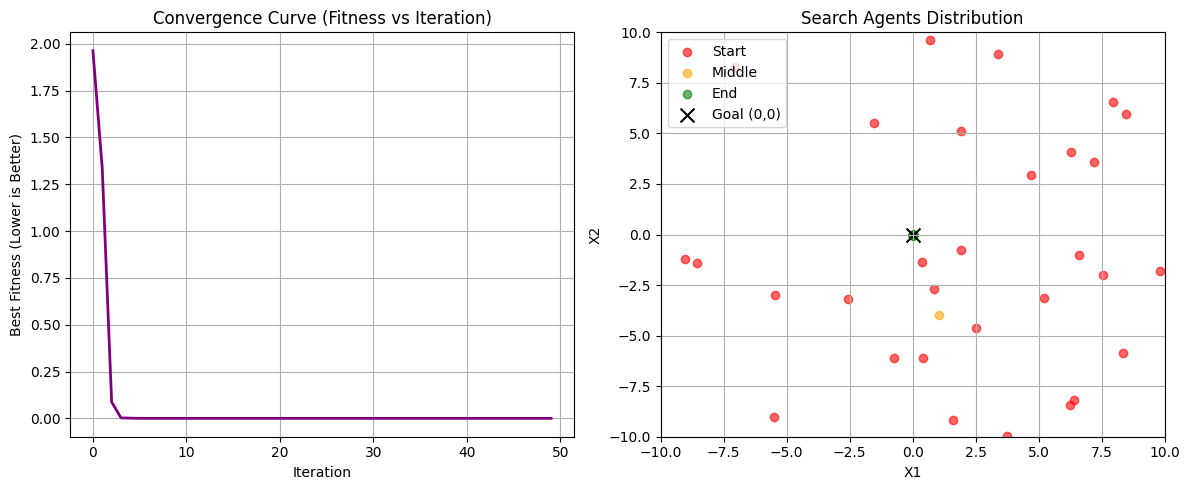

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. สร้างฟังก์ชันเป้าหมาย (Objective Function)
# สมมติเป็นรูปถ้วยหงาย (Sphere Function) จุดต่ำสุดคือ (0,0)
def objective_function(x):
    return np.sum(x**2)

# 2. ตั้งค่าพารามิเตอร์ SMA
pop_size = 30       # จำนวนราเมือก
max_iter = 50       # จำนวนรอบการค้นหา
dim = 2             # พื้นที่ 2 มิติ (X, Y)
lb, ub = -10, 10    # ขอบเขตการค้นหา (-10 ถึง 10)

# เริ่มต้นประชากรราเมือก (สุ่มตำแหน่ง)
X = np.random.uniform(lb, ub, (pop_size, dim))
fitness = np.array([objective_function(ind) for ind in X])

# ตัวแปรสำหรับเก็บข้อมูลเพื่อวาดกราฟ
convergence_curve = []
history_pos = []

# 3. เริ่มกระบวนการค้นหา (Main Loop)
for t in range(max_iter):
    # เรียงลำดับความเก่ง (Fitness)
    sorted_indices = np.argsort(fitness)
    X = X[sorted_indices]
    fitness = fitness[sorted_indices]

    # เก็บค่าที่ดีที่สุดในรอบนี้
    best_fitness = fitness[0]
    best_pos = X[0]
    convergence_curve.append(best_fitness)

    # เก็บตำแหน่งของราเมือกทุกตัวไว้แสดงผล (เฉพาะรอบแรก, กลาง, ท้าย)
    if t == 0 or t == max_iter//2 or t == max_iter-1:
        history_pos.append(X.copy())

    # คำนวณค่า Weight (W) ตามสูตร SMA (แบบย่อ)
    w = np.zeros((pop_size, dim))
    for i in range(pop_size):
        condition = i < pop_size / 2 # ครึ่งบนที่เก่งกว่า
        if condition:
            w[i] = 1 + np.random.rand() * np.log10((best_fitness - fitness[i]) / (best_fitness - fitness[-1] + 1e-10) + 1)
        else:
            w[i] = 1 - np.random.rand() * np.log10((best_fitness - fitness[i]) / (best_fitness - fitness[-1] + 1e-10) + 1)

    # อัปเดตตำแหน่ง (Position Update)
    a = np.arctanh(1 - (t/max_iter) - 1e-9) # แก้ไข: ลดค่าจาก 1 เล็กน้อยเพื่อป้องกัน arctanh(1) = inf
    b = 1 - (t/max_iter)

    for i in range(pop_size):
        if np.random.rand() < 0.03: # โอกาสสุ่มไปที่ใหม่เลย (Exploration)
            X[i] = np.random.uniform(lb, ub, dim)
        else:
            p = np.tanh(abs(fitness[i] - best_fitness))
            vb = np.random.uniform(-a, a, dim)
            vc = np.random.uniform(-b, b, dim)

            r = np.random.rand()
            if r < p:
                X[i] = best_pos + vb * (w[i] * X[np.random.randint(0, pop_size)] - X[np.random.randint(0, pop_size)])
            else:
                X[i] = vc * X[i]

    # ปรับปรุง Fitness ใหม่
    X = np.clip(X, lb, ub) # ห้ามออกนอกกรอบ
    fitness = np.array([objective_function(ind) for ind in X])

# 4. แสดงผลกราฟ
plt.figure(figsize=(12, 5))

# กราฟที่ 1: Convergence Curve (กราฟการลู่เข้า)
plt.subplot(1, 2, 1)
plt.plot(convergence_curve, color='purple', linewidth=2)
plt.title('Convergence Curve (Fitness vs Iteration)')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness (Lower is Better)')
plt.grid(True)

# กราฟที่ 2: Search Space (การกระจายตัว 2 มิติ)
plt.subplot(1, 2, 2)
colors = ['red', 'orange', 'green'] # แดง=เริ่ม, ส้ม=กลาง, เขียว=จบ
labels = ['Start', 'Middle', 'End']

for i, pos in enumerate(history_pos):
    plt.scatter(pos[:, 0], pos[:, 1], c=colors[i], label=labels[i], alpha=0.6)

plt.scatter(0, 0, c='black', marker='x', s=100, label='Goal (0,0)') # เป้าหมาย
plt.title('Search Agents Distribution')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True)
plt.xlim(lb, ub)
plt.ylim(lb, ub)

plt.tight_layout()
plt.show()